# Import Modules and Functions

In [1]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
## reference tables
table_a57 = pd.read_csv('LC_tables/data/LCref_a57_g.csv')
table_a54 = pd.read_csv('LC_tables/data/LCref_a54_g.csv')

## segment 1
lc_df1 = readin_LCdf('LC_tables/data/LCtable1_g.csv')

## segment 2
lc_df2 = readin_LCdf('LC_tables/data/LCtable2_g.csv')

## segment 3
lc_df3 = readin_LCdf('LC_tables/data/LCtable3_g.csv')

## segment 4
lc_df4 = readin_LCdf('LC_tables/data/LCtable4_g.csv')

In [4]:
### Some images need to be excluded due to quality
### Images from ccd 54 have bad bands (mainly filter i is affected)

# badims_a54g = pd.read_csv('txt_files/ec0915a54g_badims.txt', header=None)[0]
# bad_expnums_a54g = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54g]


bad_expnums_a54g = pd.read_csv('txt_files/a54g_badims.csv')['a54'].values
bad_expnums_a57g = pd.read_csv('txt_files/a57g_badims.csv')['a57'].values

# bad_expnums_a54g = None
# bad_expnums_a57g = None

# Combine LCs

### Fitting Process for Each Segment

In [5]:
# ### Define uncertainty/error cut on flux error

f_lim = 20.0               # upper limit of flux (muJyas2)
ferr_lim = 1.0            # upper limit of flux error (muJyas2_err)

# ### The working indices for fitting process -- run before the rest
bin_sz = None
flag_inds(lc_df1, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a57g, bin_size=bin_sz)
flag_inds(lc_df2, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g, bin_size=bin_sz)
flag_inds(lc_df3, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g, bin_size=bin_sz)
flag_inds(lc_df4, f_lm=f_lim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g, bin_size=bin_sz)

'Updated LC dataframe -- flagged working indices'

In [6]:
### Fit LCs to a template
### 1st iteration --> template is an individual LC


### Use same tshifts as in filter i
iparms1 = pd.read_csv('LC_tables/fit_params/fparams_i1.csv').values
iparms2 = pd.read_csv('LC_tables/fit_params/fparams_i2.csv').values
iparms3 = pd.read_csv('LC_tables/fit_params/fparams_i3.csv').values
iparms4 = pd.read_csv('LC_tables/fit_params/fparams_i4.csv').values


## segment 1
templ_ID1 = 2
fit_parms1 = fit_LCs(lc_df1, templ_ID=templ_ID1, tshift_ls=iparms1[1])

## segment 2
templ_ID2 = 34
fit_parms2 = fit_LCs(lc_df2, templ_ID=templ_ID2, tshift_ls=iparms2[1])

## segment 3
templ_ID3 = 90
fit_parms3 = fit_LCs(lc_df3, templ_ID=templ_ID3, tshift_ls=iparms3[1])

## segment 4
templ_ID4 = 0
fit_parms4 = fit_LCs(lc_df4, templ_ID=templ_ID4, tshift_ls=iparms4[1])

In [7]:
### Create data frame of aligned and combined LCs

## segment 1
comb1 = get_combLCs(lc_df1, fit_parms1)

## segment 2
comb2 = get_combLCs(lc_df2, fit_parms2)

## segment 3
comb3 = get_combLCs(lc_df3, fit_parms3)

## segment 4
comb4 = get_combLCs(lc_df4, fit_parms4)

In [8]:
### Get LC curve fit

## segment 1
c_t1, c_mu1, c_std1 = get_LCfit(comb1, metric=5e4)

## segment 2
c_t2, c_mu2, c_std2 = get_LCfit(comb2, metric=5e4)

## segment 3
c_t3, c_mu3, c_std3 = get_LCfit(comb3, metric=5e4)

## segment 4
c_t4, c_mu4, c_std4 = get_LCfit(comb4, metric=5e4)

### See/Check Fitting Process

In [9]:
### See individual LCs

## 4 segments (labelled 1-4)

# plot_lcs(lc_df2)
# plot_lcs(lc_df2, plot_orig=True)
# plot_lcs(lc_df1, plt_xl=60400)

In [10]:
### Check how peaks are found

# ch_df = lc_df1
# lc_ids = np.unique(ch_df.t['ID'])
# for i in lc_ids: 
#     check_inds = np.where(ch_df.t['ID'].eq(i) & ch_df.t['g_ixs_flag'].eq(True))[0]
#     ch_t, ch_mu, ch_std = get_LCfit(ch_df,indices=check_inds, metric=1e5)

#     plt.scatter(ch_df.t.loc[check_inds,'mjd'], ch_df.t.loc[check_inds,'muJyas2'])
#     plt.scatter(ch_t,ch_mu)

#     tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None)
#     # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57000,57900])
#     # plt.axvline(tpeak)
    
#     plt.show()

In [11]:
### See Fitting Process

# df = lc_df2
# fit_ps = fit_parms2
# t_ID = templ_ID2

# plot_LCfits(df,fit_ps, templ_ID=t_ID)

In [12]:
### See comb LCs

# df = lc_df1
# fit_ps = fit_parms1
# t_ID = templ_ID1

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i)
#     plt.errorbar(df.t.loc[df_inds,'new_mjd'], df.t.loc[df_inds,'new_muJyas2'], yerr=df.t.loc[df_inds,'new_muJyas2_err'], fmt='.-', ecolor='black')

In [13]:
### See combined LC

# c_df = comb1
# t_mns = c_t1
# f_mns = c_mu1
# f_mers = c_std1

# plt.errorbar(c_df.t['mjd'], c_df.t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(t_mns, f_mns, fmt='--.', ecolor='black', color='orange') #,yerr=f_mers

# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# plt.show()

# Model LC

### Combine Segments

In [14]:
### Fit segments with overlap

# Use same timeshifts as in filter i
tshiftsm_i = pd.read_csv('LC_tables/fit_params/mtshifts_i1.csv')['tshift'].values

tshiftm21, am21, bm21 = get_tshift_scale_offset(c_t2, c_mu2, c_std2, c_t1, c_mu1, c_std1, tshift_d=tshiftsm_i[0])

tshiftm23, am23, bm23 = get_tshift_scale_offset(c_t2, c_mu2, c_std2, c_t3, c_mu3, c_std3, tshift_d=tshiftsm_i[2])


# # fit segment 4 to segment 3 after its been fitted to segment 2
# m_t3 = c_t3-tshiftm23
# m_f3 = am23*c_mu3+bm23
# m_ferr3 = am23*c_std3

# tshiftm34, am34, bm34 = get_tshift_scale_offset(m_t3, m_f3, m_ferr3, c_t4, c_mu4, c_std4, tshift_d=tshiftsm_i[3])


# ## From running with bad images
# tshiftm21 = tshiftsm_i[0]
# am21 = 3.94
# bm21 = -8.18

# tshiftm23 = tshiftsm_i[2]
# am23 = 2.59
# bm23 = -5.27

tshiftm34 = tshiftsm_i[3]
am34 = 3.39
bm34 = -4.75

In [15]:
print(tshiftm34, am34, bm34)

-4450.0 3.39 -4.75


In [16]:
### Combine Segments
    ## Combine model data

# offsetm = 11.       # look at plot to decide
offsetm = 10.4

m_t1 = c_t1-tshiftm21
m_f1 = (am21*c_mu1+bm21)+offsetm
m_ferr1 = am21*c_std1

m_t2 = c_t2
m_f2 = c_mu2+offsetm
m_ferr2 = c_std2

m_t3 = c_t3-tshiftm23
m_f3 = (am23*c_mu3+bm23)+offsetm
m_ferr3 = am23*c_std3

m_t4 = c_t4-tshiftm34
m_f4 = (am34*c_mu4+bm34)+offsetm
m_ferr4 = am34*c_std4

In [17]:
### Combine Segments
    ## Combine LC data

fin_t1 = comb1.t['mjd'].values-tshiftm21
fin_f1 = (am21*comb1.t['muJyas2'].values+bm21)+offsetm
fin_ferr1 = am21*comb1.t['muJyas2_err'].values

fin_t2 = comb2.t['mjd'].values
fin_f2 = comb2.t['muJyas2'].values+offsetm
fin_ferr2 = comb2.t['muJyas2_err'].values

fin_t3 = comb3.t['mjd'].values-tshiftm23
fin_f3 = (am23*comb3.t['muJyas2'].values+bm23)+offsetm
fin_ferr3 = am23*comb3.t['muJyas2_err'].values

fin_t4 = comb4.t['mjd'].values-tshiftm34
fin_f4 = (am34*comb4.t['muJyas2'].values+bm34)+offsetm
fin_ferr4 = am34*comb4.t['muJyas2_err'].values


tls_m = np.concatenate([fin_t1, fin_t2, fin_t3, fin_t4])
fls_m = np.concatenate([fin_f1, fin_f2, fin_f3, fin_f4])
ferrls_m = np.concatenate([fin_ferr1, fin_ferr2, fin_ferr3, fin_ferr4])

ord_inds_m = tls_m.argsort()
tls_m = tls_m[ord_inds_m]
fls_m = fls_m[ord_inds_m]
ferrls_m = ferrls_m[ord_inds_m]

comb_m_data = {'mjd': tls_m, 'muJyas2': fls_m, 'muJyas2_err': ferrls_m}
comb_m = pdastrostatsclass()
comb_m.t = comb_m.t.assign(**comb_m_data)

## Save table for bookkeeping purposes
comb_m.t.to_csv('LC_tables/models/gLC_data1.csv', index=False)

In [18]:
### Create the model (LC_0)

m_t, m_mu, m_std = get_LCfit(comb_m, metric=3e4)

lc_model = {'mjd':m_t, 'muJyas2':m_mu, 'muJyas2_err':m_std}
lc_model_d = pd.DataFrame(lc_model)

lc_model_d.to_csv('LC_tables/models/gLC_m1.csv', index=False)

### See Model Fitting

In [19]:
### Individual Segements

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD (days)')

# axs[0].errorbar(c_t1, c_mu1, yerr=c_std1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# axs[1].errorbar(c_t2, c_mu2, yerr=c_std2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# axs[2].errorbar(c_t3, c_mu3, yerr=c_std3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# axs[3].errorbar(c_t4, c_mu4, yerr=c_std4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
#     ax.legend(fontsize = 14)


# # axs[1].axvline(find_t_peak(c_t2,c_mu2,c_std2, metric=None, t_range=[59000,60000]))
# # axs[2].axvline(find_t_peak(c_t3,c_mu3,c_std3, metric=None, t_range=[57000,57800]))

# # pl_fig.savefig('../figures/display/EtaCar_PiecesM.png', bbox_inches = 'tight', dpi=100)

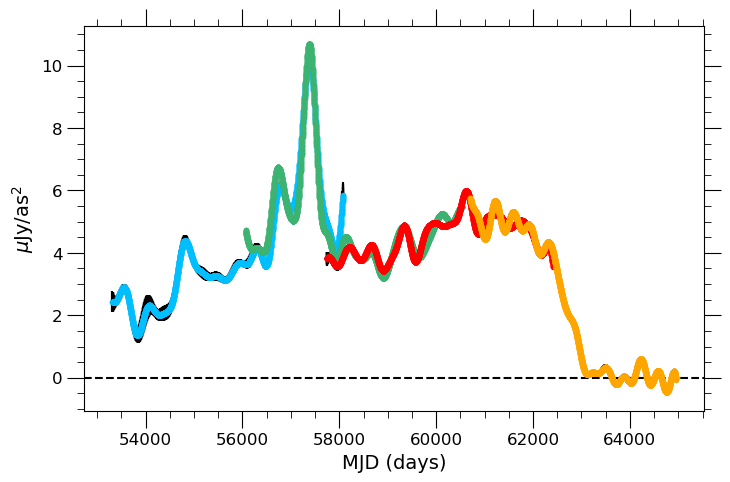

In [20]:
### See Connected Segments

fig, ax = plt.subplots(dpi = 100, figsize = [8,5])
ax.minorticks_on()
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
ax.set_xlabel('MJD (days)', fontsize = 14)
ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
ax.ticklabel_format(axis='both', style='plain')


ax.errorbar(m_t1, m_f1, yerr=m_ferr1, fmt='--.', ecolor='black', color='deepskyblue', label='Loc 1')
ax.errorbar(m_t2, m_f2, yerr=m_ferr2, fmt='--.', ecolor='black', color='mediumseagreen', label='Loc 2')
ax.errorbar(m_t3, m_f3, yerr=m_ferr3, fmt='--.', ecolor='black', color='red', label='Loc 3')
ax.errorbar(m_t4, m_f4, yerr=m_ferr4, fmt='--.', ecolor='black', color='orange', label='Loc 4')

ax.axhline(y=0, ls='--', color='k')

(-3.0, 15.0)

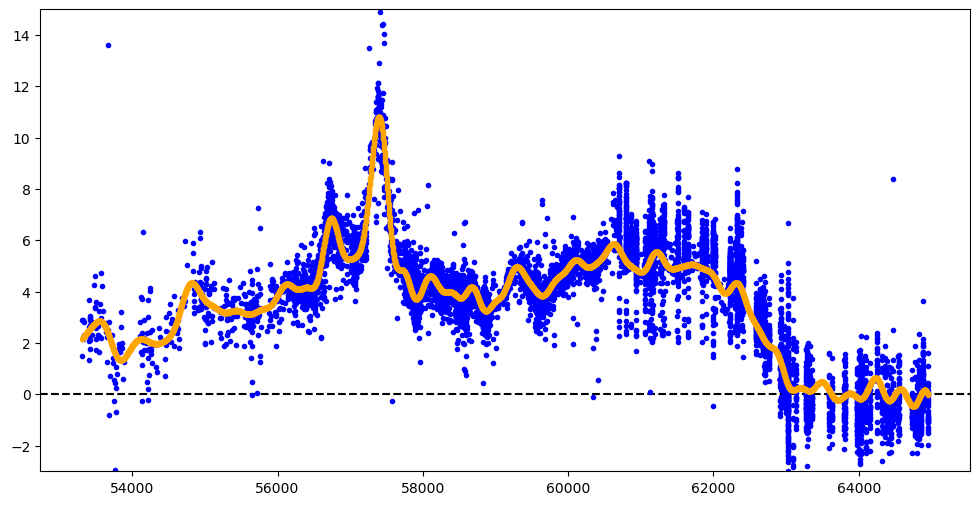

In [21]:
### Plot Model
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_m.t['mjd'], comb_m.t['muJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(m_t, m_mu, fmt='--.', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')
plt.ylim(-3,15)